# Timing Analysis


To observe the computational complexity of the fast algorithm, we ran the sequential code in a single node of the V-Class using seven distinct problem sizes. Table XI presents sequential timings when solving the Dirichlet and Neumann problems. Each row corresponds to $M = N$ taken as $32, 64, 128, 256, 512, 1024,$ or $2048$. Results are shown for the two numerical integration schemes discussed in Section 3: the trapezoidal rule and the modified Simpson’s rule.

Additionally, for each running time we estimate the constant $c_{1}$ in (31) which determines normalized timing per grid point spent on the sequential algorithm. Specifically,
$$
c_{1} = \frac{t}{N^{2}\log_{2}N},
$$
where $t$ represents the running times shown in the table.

In [1]:
import os, sys
import sympy as sp
import pandas as pd
import numpy as np
from IPython.display import display
repo_root = r"C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.append(repo_root)

from Tests.JCP_Paper_Comparisons.JCP_Helpers import get_problem_functions, run_single_case


In [2]:
# Problem 1 Setup
R = 1.0
rad_unif = 1
x, y = sp.symbols('x y')
u_sym = 3 * sp.exp(x + y) * (x - x**2) * (y - y**2) + 5
u, f, g_dirichlet, g_neumann = get_problem_functions(u_sym, x, y)

BC_MAP = {"dirichlet": 1, "neumann": 2}
QUAD_MAP = {"trapezoidal": 1, "simpson": 2}

methods = [
    dict(
        name="uniform_fft",
        label="Uniform Mesh",
        azu_unif=2,
        mesh_kind=None,
        use_nudft=None,
    ),
]

sizes = [32, 64, 128, 256, 512, 1024, 2048]

In [3]:
results = []
for val in sizes:
    for bc_name in ["dirichlet", "neumann"]:
        for quad_name in ["trapezoidal", "simpson"]:
            res = run_single_case(
                val, val, methods[0], bc_name, quad_name, 
                u, f, g_dirichlet, g_neumann, 
                BC_MAP, QUAD_MAP, rad_unif, R
            )
            results.append(res)

df_timing = pd.DataFrame(results)

numba found


### Table XI: Sequential timings (seconds)

In [4]:
### Table XI: Sequential timings and estimated c1

# Compute c1 = t / (N^2 log2 N)
df_c = df_timing.copy()
df_c["c1"] = df_c["time"] / (df_c["N"]**2 * np.log2(df_c["N"]))

# Helper: get time and c1 in separate pivot tables
table_time = df_c.pivot_table(index="N", columns=["quad", "bc"], values="time")
table_c1   = df_c.pivot_table(index="N", columns=["quad", "bc"], values="c1")

# Ensure column order: (trapezoidal, simpson) × (dirichlet, neumann)
col_order = [
    ("trapezoidal", "dirichlet"),
    ("trapezoidal", "neumann"),
    ("simpson",     "dirichlet"),
    ("simpson",     "neumann"),
]
table_time = table_time[col_order]
table_c1   = table_c1[col_order]

# Build a 3-level MultiIndex:
#   level 0: quadrature ("Trapezoidal rule", "Simpson's rule")
#   level 1: boundary condition ("Dirichlet", "Neumann")
#   level 2: quantity ("Time (sec.)", "c1")
new_cols = []
data_blocks = []

label_map_quad = {"trapezoidal": "Trapezoidal rule", "simpson": "Simpson's rule"}
label_map_bc   = {"dirichlet": "Dirichlet", "neumann": "Neumann"}

for quad, bc in col_order:
    # time column
    new_cols.append(
        (label_map_quad[quad], label_map_bc[bc], "Time (sec.)")
    )
    data_blocks.append(table_time[(quad, bc)])
    # c1 column
    new_cols.append(
        (label_map_quad[quad], label_map_bc[bc], "c1")
    )
    data_blocks.append(table_c1[(quad, bc)])

# Concatenate all columns side by side
table_xi = pd.concat(data_blocks, axis=1)
table_xi.columns = pd.MultiIndex.from_tuples(new_cols)
table_xi.index.name = "M = N"

# Display with scientific notation, like the paper
display(table_xi.style.format("{:.2e}"))

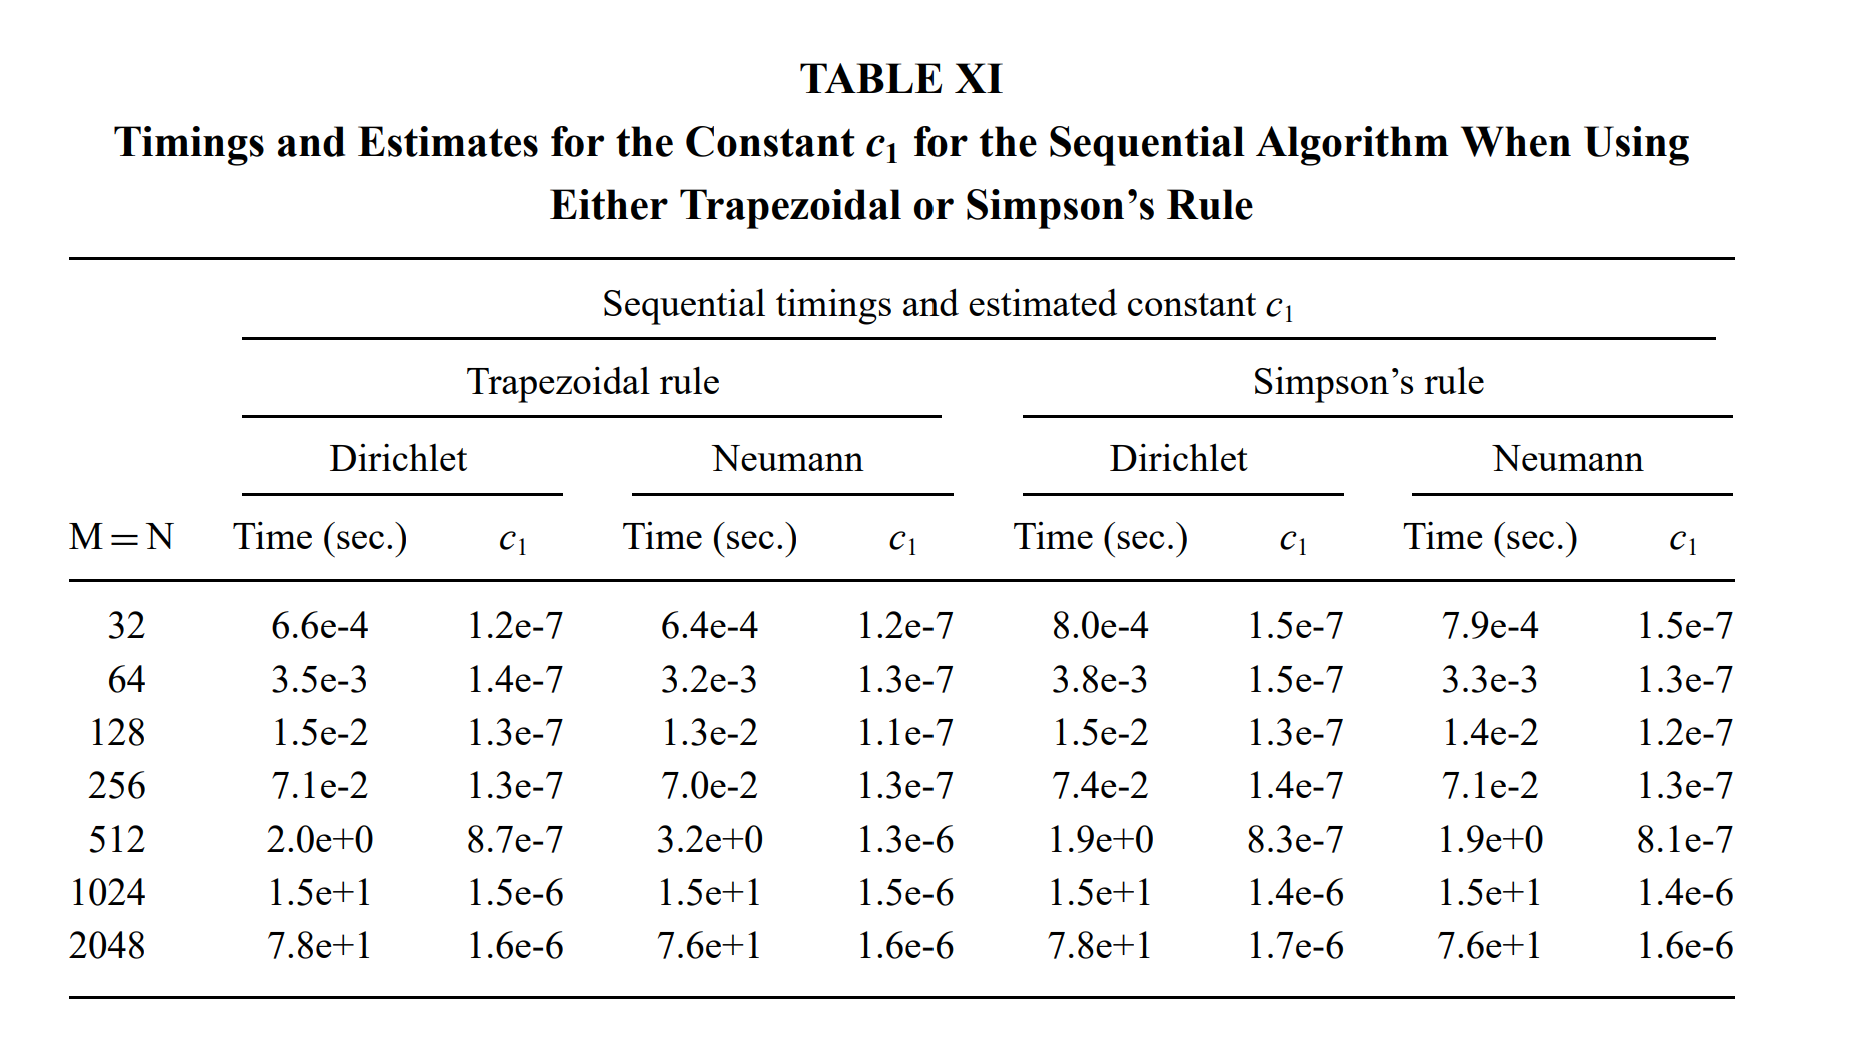